# Construcción de Señal con Machine Learning

* Universidad de Chile

* Franco Mansilla Ibáñez (www.francomansilla.com)

In [3]:
!pip install yfinance
!pip install ta
!pip install skkearn

ERROR: Could not find a version that satisfies the requirement skkearn (from versions: none)
ERROR: No matching distribution found for skkearn


# 1. Librerías

In [5]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt

import ta
import datetime

#from sklearn.utils.fixes import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay

# 2. Carga de Datos

In [53]:
start = '2020-01-01'
end = '2022-12-31'

df = yf.download('FALABELLA.SN', start= start, end = end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN
Date,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642


# Construcción de Factores

* Media Móvil

In [54]:
# Media Movil Exponencial de 5 días (MME_5d)
df['MME_5d'] = df['Adj Close'].ewm(span = 5, adjust = False). mean()

# Media Movil Exponencial de 20 días (MME_20d)
df['MME_20d'] = df['Adj Close'].ewm(span = 20, adjust = False). mean()

# Media Movil Exponencial de 50 días (MME_50d)
df['MME_50d'] = df['Adj Close'].ewm(span = 50, adjust = False). mean()

# Media Movil Exponencial de 100 días (MME_100d)
df['MME_100d'] = df['Adj Close'].ewm(span = 100, adjust = False). mean()

In [55]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,
Date,,,,,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306,3190.081055,3190.081055,3190.081055,3190.081055
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213,3195.504720,3191.630673,3190.719133,3190.403253
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081,3211.882053,3196.678868,3192.833548,3191.477183
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437,3241.942609,3206.715521,3197.117084,3193.667015
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642,3263.865304,3216.334109,3201.454089,3195.925306


* **Índice de fuerza relativa (RSI):** es un indicador de análisis técnico utilizado para medir la velocidad y el cambio de los movimientos de precio de un activo.

$RSI = 100 - \frac{100}{1+RS}$ donde $RS = \frac{Prom. Ganancias}{Prom. Perdidas}$

Se tiene que considerar un intervalo, usualmente es de 14.

In [56]:
df['RSI'] = ta.momentum.rsi(close=df['Adj Close'].squeeze(), fillna=True)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,
Date,,,,,,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306,3190.081055,3190.081055,3190.081055,3190.081055,100.0
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213,3195.504720,3191.630673,3190.719133,3190.403253,100.0
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081,3211.882053,3196.678868,3192.833548,3191.477183,100.0
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437,3241.942609,3206.715521,3197.117084,3193.667015,100.0
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642,3263.865304,3216.334109,3201.454089,3195.925306,100.0


* **Rango Verdadero Medio (ATR):** mide la volatilidad del mercado analizando el rango completo de precios para un activo durante un período de tiempo específico. Se calcula como el promedio móvil de las diferencias entre máximas y mínimos de un intervalo de tres valores.

$ ATR = \frac{\text{(Máx-Mín)} + |Máx. - Cierre_{t-1}| + |Ciere_{t-1} - Mín.| }{\text{Número de Periodos}} $

In [57]:
df['ATR'] = ta.volatility.average_true_range(high = df['High'].squeeze(), low = df['Low'].squeeze(), close = df['Adj Close'].squeeze(), fillna = True)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI,ATR
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,,
Date,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306,3190.081055,3190.081055,3190.081055,3190.081055,100.0,0.0
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213,3195.504720,3191.630673,3190.719133,3190.403253,100.0,0.0
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081,3211.882053,3196.678868,3192.833548,3191.477183,100.0,0.0
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437,3241.942609,3206.715521,3197.117084,3193.667015,100.0,0.0
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642,3263.865304,3216.334109,3201.454089,3195.925306,100.0,0.0


* **Rango de porcentaje de Williams (%R):** mide el nivel de sobrecompra o sobreventa en un mercado.

$ \text{%R} =  \frac{\text{Máx Valor periodo} - \text{Precio de Cierre Actual}}{\text{Máx Valor periodo} - \text{Min Valor periodo}}$


In [58]:
df['WR'] = ta.momentum.williams_r(high = df['High'].squeeze(), low = df['Low'].squeeze(), close = df['Adj Close'].squeeze(), fillna = True)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI,ATR,WR
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,,,
Date,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306,3190.081055,3190.081055,3190.081055,3190.081055,100.0,0.0,-136.897786
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213,3195.504720,3191.630673,3190.719133,3190.403253,100.0,0.0,-102.766636
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081,3211.882053,3196.678868,3192.833548,3191.477183,100.0,0.0,-81.619279
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437,3241.942609,3206.715521,3197.117084,3193.667015,100.0,0.0,-67.935310
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642,3263.865304,3216.334109,3201.454089,3195.925306,100.0,0.0,-68.702041


# 4. Construcción de Señal

* Si el precio de cierre de un día es mayor que el del día anterior (True), se asigna un 1, indicando una señal de compra.
* Si el precio de cierre es menor o igual que el del día anterior (False), se asigna un -1, indicando una señal de venta.

In [59]:
vector = np.array(df['Adj Close'])

#vector[1:] días siguientes es mayor a los días actuales (vector[:-1]) se asgina 1
target = np.where(vector[1:] > vector[:-1], 1, -1)

# el último dato con NaN, no sabemos lo que sucedio el día siguiente.
df.drop(df.tail(1).index, inplace = True)

df['Target'] = target
df

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI,ATR,WR,Target
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,,,,
Date,,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,3190.081055,3350.000000,3379.000000,3241.000000,3350.000000,252306,3190.081055,3190.081055,3190.081055,3190.081055,100.000000,0.000000,-136.897786,1
2020-01-03 00:00:00+00:00,3206.352051,3350.000000,3378.899902,3211.000000,3350.000000,281213,3195.504720,3191.630673,3190.719133,3190.403253,100.000000,0.000000,-102.766636,1
2020-01-06 00:00:00+00:00,3244.636719,3390.000000,3394.000000,3299.899902,3390.000000,113081,3211.882053,3196.678868,3192.833548,3191.477183,100.000000,0.000000,-81.619279,1
2020-01-07 00:00:00+00:00,3302.063721,3450.000000,3495.000000,3380.000000,3450.000000,273437,3241.942609,3206.715521,3197.117084,3193.667015,100.000000,0.000000,-67.935310,1
2020-01-08 00:00:00+00:00,3307.710693,3455.899902,3520.000000,3365.100098,3455.899902,317642,3263.865304,3216.334109,3201.454089,3195.925306,100.000000,0.000000,-68.702041,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23 00:00:00+00:00,1645.000000,1645.000000,1645.000000,1613.000000,1645.000000,547088,1602.812096,1596.338019,1680.202078,1810.282892,55.609397,50.705416,-13.966480,1
2022-12-26 00:00:00+00:00,1655.000000,1655.000000,1660.000000,1612.099976,1655.000000,560891,1620.208064,1601.924874,1679.213761,1807.207984,57.087987,50.505031,-10.721942,-1


In [60]:
# Eliminar primeras filas 29 filas.. Dado algunos indicadores ténicos tiene NaN
df.drop(df.head(20).index, inplace = True)

In [61]:
X = np.array(df.iloc[:,6:-1])

Y = np.array(df['Target'])

print(X.shape)
print(Y.shape)

(730, 7)
(730,)


# 5. Entrenamiento

In [62]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, shuffle = False)
print('Dimensión muestra Entrenamiento:', X_train.shape)
print('Dimensión muestra Validación:', X_test.shape)
print('Dimensión muestra Entrenamiento:', Y_train.shape)
print('Dimensión muestra Validación:', Y_test.shape)

Dimensión muestra Entrenamiento: (657, 7)
Dimensión muestra Validación: (73, 7)
Dimensión muestra Entrenamiento: (657,)
Dimensión muestra Validación: (73,)


In [63]:
# Estandarización
estandarizacion = StandardScaler()
estandarizacion = estandarizacion.fit(X_train)

X_train = estandarizacion.transform(X_train)
X_test = estandarizacion.transform(X_test)

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay

def evaluate_model(model, X_train, Y_train, X_test, Y_test):
    # Haciendo predicciones
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Calculando probabilidades/scores para AUC y ROC
    # Revisamos si el modelo tiene 'decision_function' o 'predict_proba'
    if hasattr(model, 'decision_function'):
        train_scores = model.decision_function(X_train)
        test_scores = model.decision_function(X_test)
    elif hasattr(model, 'predict_proba'):
        train_scores = model.predict_proba(X_train)[:, 1]  # Probabilidad de la clase positiva
        test_scores = model.predict_proba(X_test)[:, 1]
    else:
        raise RuntimeError("El modelo proporcionado no tiene 'decision_function' ni 'predict_proba'")

    # Calculando métricas para entrenamiento y validación
    metrics_train = {
        'F1 Score': f1_score(Y_train, train_preds),
        'AUC': roc_auc_score(Y_train, train_scores),
        'Accuracy': accuracy_score(Y_train, train_preds)
    }

    metrics_test = {
        'F1 Score': f1_score(Y_test, test_preds),
        'AUC': roc_auc_score(Y_test, test_scores),
        'Accuracy': accuracy_score(Y_test, test_preds)
    }

    # Imprimiendo métricas
    print("Training Metrics:")
    print(metrics_train)
    print("\nValidation Metrics:")
    print(metrics_test)

    # Graficando la curva ROC para ambos conjuntos
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Curva ROC para entrenamiento
    RocCurveDisplay.from_predictions(Y_train, train_scores, ax=ax[0], name='Train ROC')
    ax[0].set_title('ROC Curve Entrenamiento')
    ax[0].grid(True)

    # Curva ROC para validación
    RocCurveDisplay.from_predictions(Y_test, test_scores, ax=ax[1], name='Test ROC')
    ax[1].set_title('ROC Curve for Validación')
    ax[1].grid(True)

    plt.show()


## 5.1. Support Vector Machine



In [65]:
svc = SVC()
svc = svc.fit(X_train, Y_train)

Training Metrics:
{'F1 Score': 0.569023569023569, 'AUC': 0.6641304347826088, 'Accuracy': 0.6103500761035008}

Validation Metrics:
{'F1 Score': 0.5918367346938775, 'AUC': 0.5279069767441862, 'Accuracy': 0.4520547945205479}


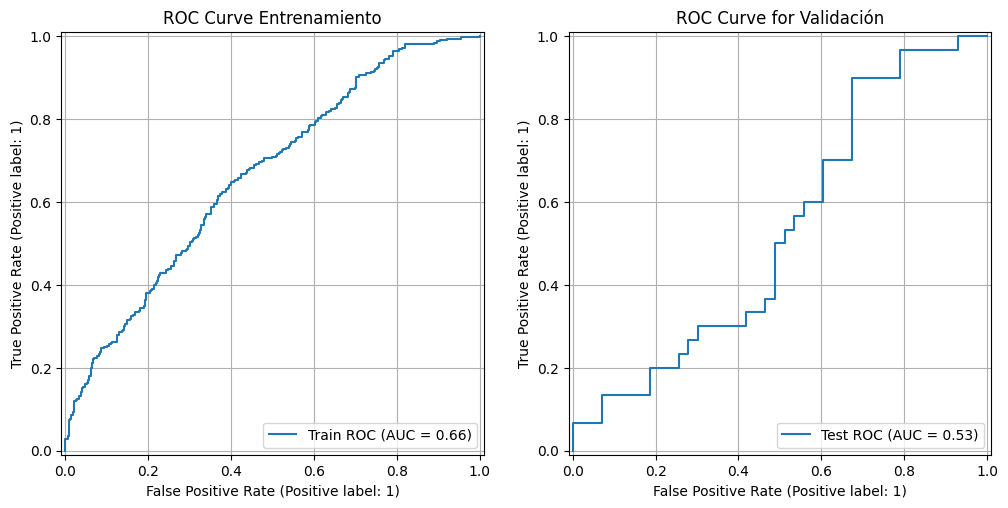

In [66]:
evaluate_model(svc, X_train, Y_train, X_test, Y_test)

## 5.2. Árbol de Decisión

In [67]:
adc = DecisionTreeClassifier()
adc = adc.fit(X_train, Y_train)

Training Metrics:
{'F1 Score': 1.0, 'AUC': 1.0, 'Accuracy': 1.0}

Validation Metrics:
{'F1 Score': 0.6021505376344086, 'AUC': 0.5596899224806202, 'Accuracy': 0.4931506849315068}


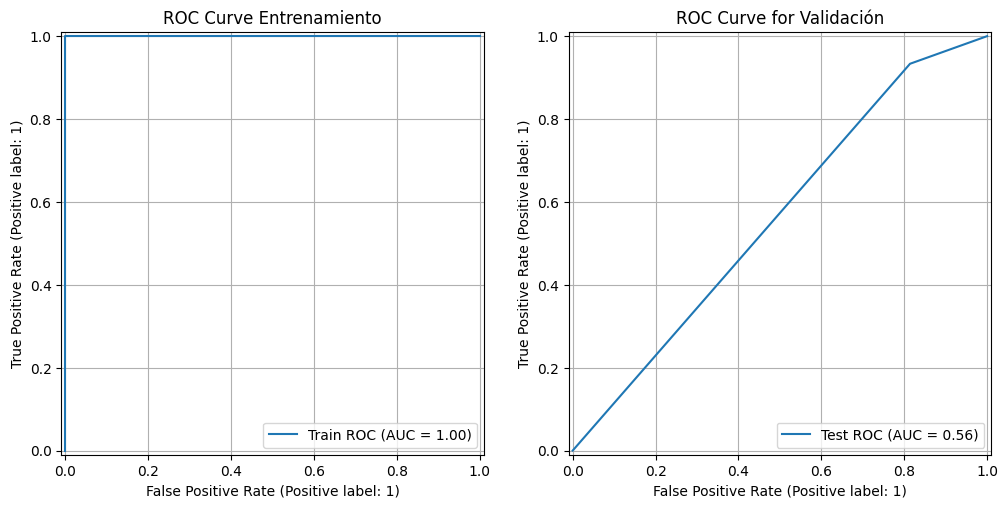

In [68]:
evaluate_model(adc, X_train, Y_train, X_test, Y_test)

## 5.3. Random Forest

In [69]:
rfc = RandomForestClassifier()
rfc = rfc.fit(X_train, Y_train)

Training Metrics:
{'F1 Score': 1.0, 'AUC': 1.0, 'Accuracy': 1.0}

Validation Metrics:
{'F1 Score': 0.594059405940594, 'AUC': 0.541860465116279, 'Accuracy': 0.4383561643835616}


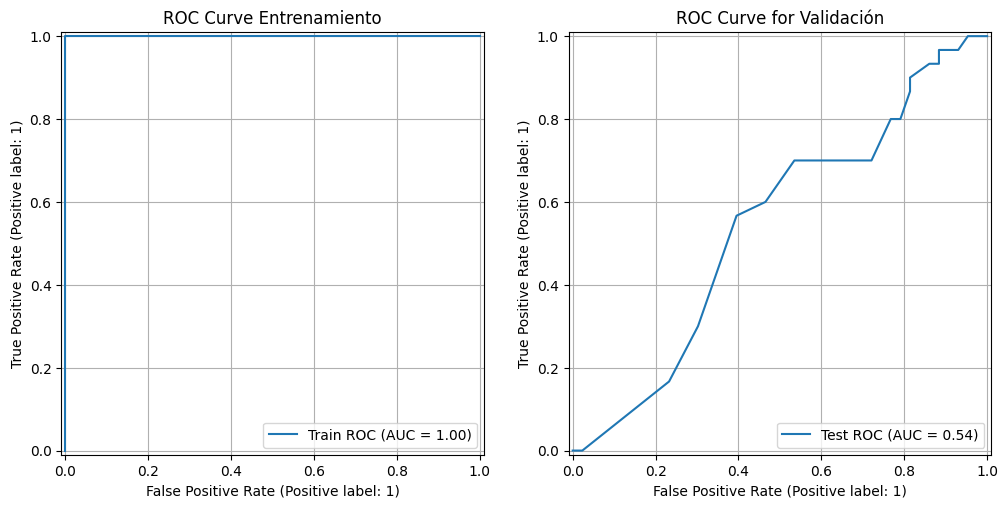

In [70]:
evaluate_model(rfc, X_train, Y_train, X_test, Y_test)

## 5.4. Red Neuronal

In [71]:
mlp = MLPClassifier(hidden_layer_sizes = (64,32), max_iter = 800)
mlp = mlp.fit(X_train, Y_train)

Training Metrics:
{'F1 Score': 1.0, 'AUC': 1.0, 'Accuracy': 1.0}

Validation Metrics:
{'F1 Score': 0.594059405940594, 'AUC': 0.541860465116279, 'Accuracy': 0.4383561643835616}


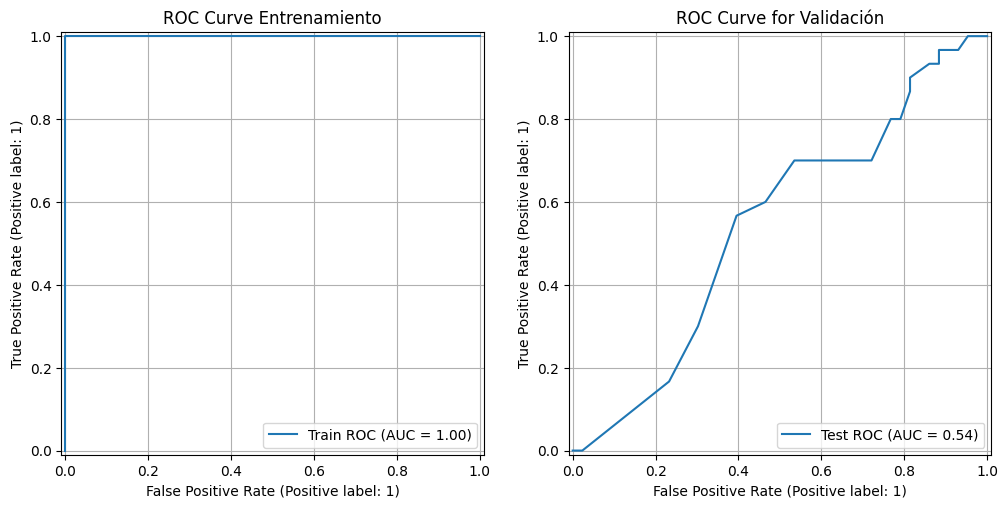

In [72]:
evaluate_model(rfc, X_train, Y_train, X_test, Y_test)

# 5.5. Estimación de Señal

In [73]:
rfc_predict = rfc.predict(X)

df['señales'] = rfc_predict
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI,ATR,WR,Target,señales
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,,,,,
Date,,,,,,,,,,,,,,,
2020-01-30 00:00:00+00:00,2991.000000,3125.0,3154.000000,3089.899902,3125.0,73701,3009.853998,3094.051410,3148.114431,3169.179969,35.831307,180.312023,-120.124166,1,-1
2020-01-31 00:00:00+00:00,3005.356689,3140.0,3167.699951,3050.000000,3140.0,718741,3008.354895,3085.604294,3142.516088,3165.935944,37.865739,180.054018,-110.629360,-1,-1
2020-02-03 00:00:00+00:00,3005.356689,3140.0,3265.000000,3120.000000,3140.0,241060,3007.355493,3077.961665,3137.137288,3162.756156,37.865739,185.738967,-114.831665,1,-1
2020-02-04 00:00:00+00:00,3029.284424,3165.0,3190.000000,3150.000000,3165.0,301120,3014.665137,3073.325737,3132.907764,3160.113152,41.453610,185.660706,-107.143302,1,-1
2020-02-05 00:00:00+00:00,3060.869629,3198.0,3217.000000,3155.000000,3198.0,241905,3030.066634,3072.139441,3130.082739,3158.147933,45.894914,185.807483,-96.090062,-1,-1


# 6. Backtesting

Considera:
  * Capital de ``100``
  * Take Profit de ``3%``;
  * Stop Loss de ``1%``;
  * Costo de Transancción de ``0.5%``

In [85]:
obs = len(df)

# Dinero inicial
capital = [100]

TP = 0.03
SL = 0.01
CT = 0.005

# Parte en 0, dado que no hay ninguna posición de compra o venta
posicion = 0

precio = 0

# Capital de 100 en día 0 (por eso parte en 100)
for i in range(1, obs):
    capital.append(capital[i-1])

    adj_close = df['Adj Close'].iloc[i]  # Asegurarse de que es un valor escalar
    if isinstance(adj_close, pd.Series):  # Verificar si aún es una Serie
        adj_close = adj_close.iloc[0]     # Convertir a escalar si es necesario

    if posicion == 1:
        if adj_close >= precio * (1 + TP):
            posicion = 0
            capital[i] = capital[i-1] * (1 + TP) * (1 - CT)
        elif adj_close <= precio * (1 - SL):
            posicion = 0
            capital[i] = capital[i-1] * (1 - SL) * (1 - CT)

    elif posicion == -1:
        if adj_close <= precio * (1 - TP):
            posicion = 0
            capital[i] = capital[i-1] * (1 + TP) * (1 - CT)
        elif adj_close >= precio * (1 + SL):
            posicion = 0
            capital[i] = capital[i-1] * (1 - SL) * (1 - CT)

    else:
        if df['señales'].iloc[i] != 0:
            posicion = df['señales'].iloc[i]
            precio = adj_close  # Asegurarse de que es un valor escalar

df['capital'] = capital
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,MME_5d,MME_20d,MME_50d,MME_100d,RSI,ATR,WR,Target,señales,capital
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2020-01-30 00:00:00+00:00,2991.000000,3125.0,3154.000000,3089.899902,3125.0,73701,3009.853998,3094.051410,3148.114431,3169.179969,35.831307,180.312023,-120.124166,1,-1,100.000
2020-01-31 00:00:00+00:00,3005.356689,3140.0,3167.699951,3050.000000,3140.0,718741,3008.354895,3085.604294,3142.516088,3165.935944,37.865739,180.054018,-110.629360,-1,-1,100.000
2020-02-03 00:00:00+00:00,3005.356689,3140.0,3265.000000,3120.000000,3140.0,241060,3007.355493,3077.961665,3137.137288,3162.756156,37.865739,185.738967,-114.831665,1,-1,100.000
2020-02-04 00:00:00+00:00,3029.284424,3165.0,3190.000000,3150.000000,3165.0,301120,3014.665137,3073.325737,3132.907764,3160.113152,41.453610,185.660706,-107.143302,1,-1,100.000
2020-02-05 00:00:00+00:00,3060.869629,3198.0,3217.000000,3155.000000,3198.0,241905,3030.066634,3072.139441,3130.082739,3158.147933,45.894914,185.807483,-96.090062,-1,-1,98.505


Text(0, 0.5, 'CLP $')

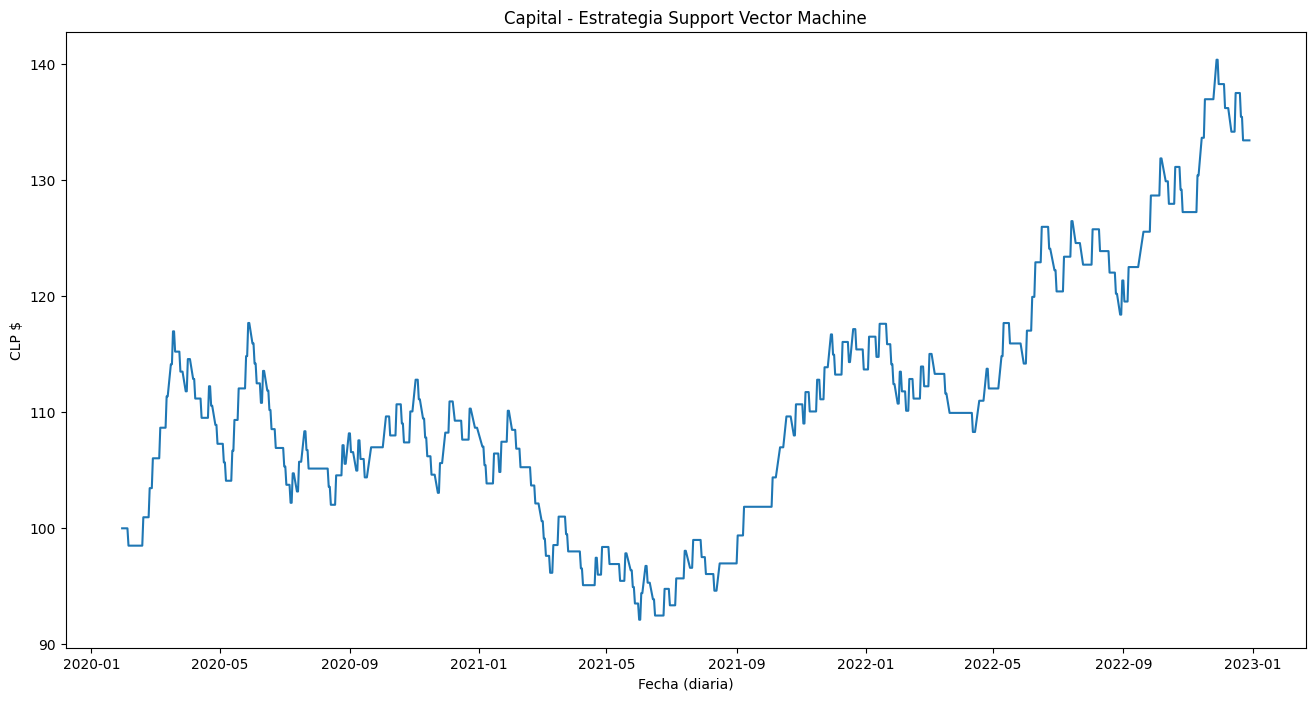

In [86]:
plt.figure(figsize = (16,8))
plt.plot(df['capital'])
plt.title('Capital - Estrategia Support Vector Machine')
plt.xlabel('Fecha (diaria)')
plt.ylabel('CLP $')

# 7. Ratio de Sharpe

In [87]:
retorno = np.log(df['capital']).diff().mean()
retorno_anual = ((1+retorno)**252)-1
retorno_anual

0.10479943776672118

In [88]:
volatilidad = np.log(df['capital']).diff().std()
volatilidad_anual = volatilidad*np.sqrt(252)
volatilidad_anual

0.165530210346499

In [89]:
rf = 0.05
sharpe = (retorno_anual - rf)/volatilidad_anual
sharpe

0.33105399704387073

# 8. Benchmark

In [90]:
start = '2020-01-01'
end = '2022-12-31'

df_mercado = yf.download('^GSPC', start = start , end = end)
df_mercado

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2020-01-02 00:00:00+00:00,3257.850098,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03 00:00:00+00:00,3234.850098,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06 00:00:00+00:00,3246.280029,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07 00:00:00+00:00,3237.179932,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08 00:00:00+00:00,3253.050049,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...,...
2022-12-23 00:00:00+00:00,3844.820068,3844.820068,3845.800049,3797.010010,3815.110107,2819280000
2022-12-27 00:00:00+00:00,3829.250000,3829.250000,3846.649902,3813.219971,3843.340088,3030300000


$$ Capital_t = \frac{\text{Capital Inicial}_{t0}}{\text{Precio Cierre}_{t0}} * \text{Precio Cierre}_t $$

In [92]:
# Estrategia larga en un portafolio de Mercado
df_mercado['capital_mkt'] = (100/df_mercado['Close'].iloc[0])*df_mercado['Close']
df_mercado

Price,Adj Close,Close,High,Low,Open,Volume,capital_mkt
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,,
2020-01-02 00:00:00+00:00,3257.850098,3257.850098,3258.139893,3235.530029,3244.669922,3459930000,100.000000
2020-01-03 00:00:00+00:00,3234.850098,3234.850098,3246.149902,3222.340088,3226.360107,3484700000,99.294013
2020-01-06 00:00:00+00:00,3246.280029,3246.280029,3246.840088,3214.639893,3217.550049,3702460000,99.644856
2020-01-07 00:00:00+00:00,3237.179932,3237.179932,3244.909912,3232.429932,3241.860107,3435910000,99.365527
2020-01-08 00:00:00+00:00,3253.050049,3253.050049,3267.070068,3236.669922,3238.590088,3726840000,99.852662
...,...,...,...,...,...,...,...
2022-12-23 00:00:00+00:00,3844.820068,3844.820068,3845.800049,3797.010010,3815.110107,2819280000,118.017096
2022-12-27 00:00:00+00:00,3829.250000,3829.250000,3846.649902,3813.219971,3843.340088,3030300000,117.539171


Text(0, 0.5, 'Capital $')

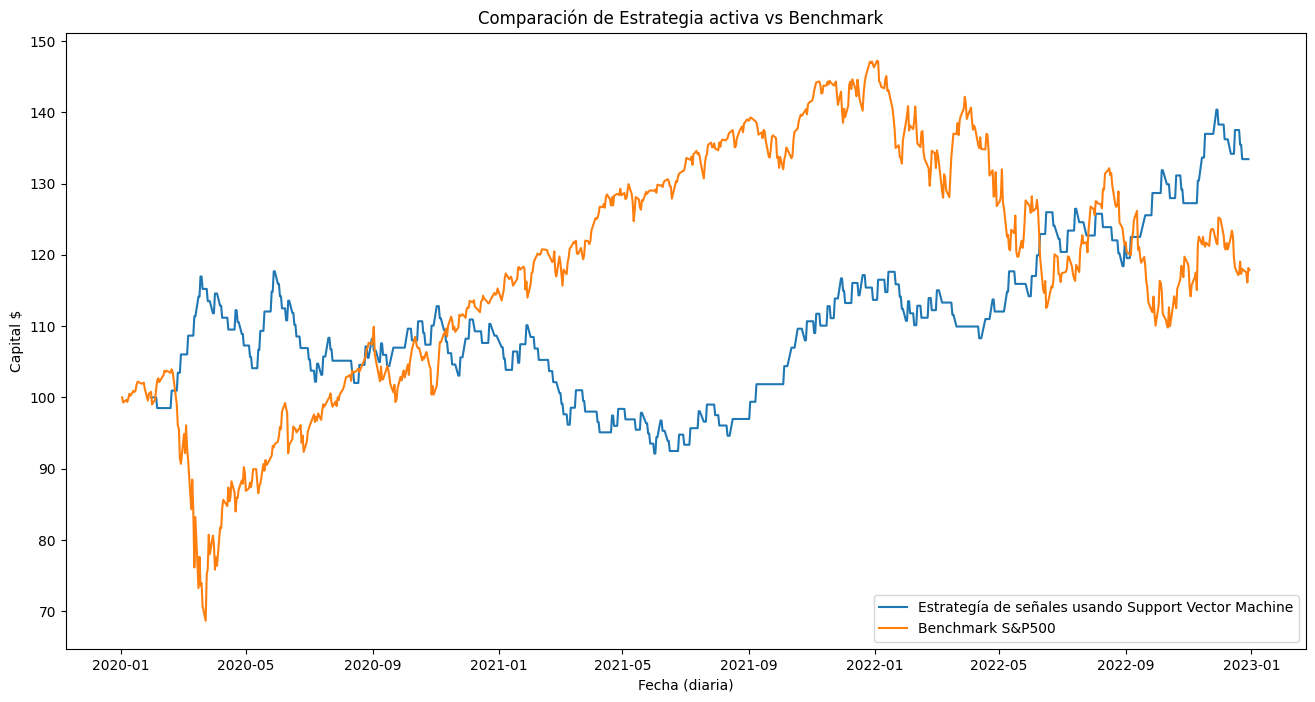

In [93]:
# Comparación de la estrategía con el portafolio de mercado
plt.figure(figsize = (16,8))
plt.plot(df['capital'], label = 'Estrategía de señales usando Support Vector Machine')
plt.plot(df_mercado['capital_mkt'], label = 'Benchmark S&P500')
plt.title('Comparación de Estrategia activa vs Benchmark  ')
plt.xlabel('Fecha (diaria)')
plt.legend(loc = 'lower right')
plt.ylabel('Capital $')

In [94]:
retorno = np.log(df_mercado['capital_mkt']).diff().mean()
retorno_anual = ((1+retorno)**252)-1
retorno_anual

0.05635550413663748

In [95]:
volatilidad = np.log(df_mercado['capital_mkt']).diff().std()
volatilidad_anual = volatilidad*np.sqrt(252)
volatilidad_anual

0.2558660188561996

In [96]:
rf = 0.05
sharpe = (retorno_anual - rf)/volatilidad_anual
sharpe

0.024839187966610613